# Vagary 原创填词作品统计

这是面向 Jupyter 的交互式统计本。请从上到下运行代码单元格（选中后按 `Shift + Enter`）。

> **首次使用**：请先在项目根目录执行 `pip install -e .` 安装 vagary 包，
> 然后点击工具栏的「全部运行」即可。

统计口径：一个词在同一首歌中出现多次，只按 **1 首作品** 计算。

In [1]:
# ===== 首次使用才需要运行此单元格 =====
# 如果 vagary 包尚未安装，取消下面两行的注释并运行一次，完成后重启内核。
# import sys; sys.path.insert(0, '..')
# !pip install -e ..

# 载入本项目的函数
from pathlib import Path

from vagary import (
    load_works, word_frequency, words_by_length, plot_frequency,
    search_word, song_high_frequency_words, collaborator_frequency,
    plot_collaborators, export_tables,
)
import matplotlib.pyplot as plt

print('准备完成。')

准备完成。


## 1. 读取数据与设置排除词、个人词典

`EXCLUDE_WORDS` 里的词将完全不计入统计。个人词典是可选项：
将 `data/personal_dict_example.txt` 复制为 `data/personal_dict.txt` 后填写文件名。

In [2]:
# 这里可以随时增删不希望被统计的词。
EXCLUDE_WORDS = {'我们', '你们','一个','什么','我的','你的','这一','的我','是我','的人'}

# 个人词典：若 data/personal_dict.txt 存在则使用，否则为 None
# 注意：本 Notebook 在 tests/ 目录下，数据文件在上级 data/ 目录
DATA_DIR = Path('..') / 'data'
USER_DICT = str(DATA_DIR / 'personal_dict.txt') if (DATA_DIR / 'personal_dict.txt').exists() else None

works = load_works(DATA_DIR / 'vagary.xlsx')
print(f'成功读取 {len(works)} 首作品。')
works[['歌曲名', '演唱', '作曲', '编曲']].head()

成功读取 132 首作品。


,歌曲名,演唱,作曲,编曲
0,Burlesque,i2star,Zoey,Zoey
1,Don't Don't,银临,小龙龙,天钦
2,No小姐,晴愔,露西Lucie,七二四
3,Silent Doll,水一,Asado,Asado
4,Yes先生,洛萱,露西Lucie,七二四


## 2. 词频统计与图表

默认优先用 jieba 分词。若本机没有 jieba，会自动以保底算法运行；
正式结果请安装依赖并可使用个人词典优化。

In [3]:
frequency = word_frequency(works, exclude_words=EXCLUDE_WORDS, user_dict=USER_DICT)
print(f'共得到 {len(frequency)} 个候选词。')
# 分别查看 2 字、3 字、4 字词；此处显示各自前 20 名。
two_char = words_by_length(frequency, 2, top_n=21)
three_char = words_by_length(frequency, 3, top_n=20)
four_char = words_by_length(frequency, 4, top_n=20)
two_char

Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\0612\AppData\Local\Temp\jieba.cache
Loading model cost 0.649 seconds.
Prefix dict has been built successfully.


共得到 8545 个候选词。


,词语,出现作品数,字数
0,人间,45,2
1,一生,35,2
2,红尘,32,2
3,天地,31,2
4,青春,29,2
5,岁月,28,2
6,少年,27,2
7,温柔,25,2
8,多少,23,2
9,生死,22,2


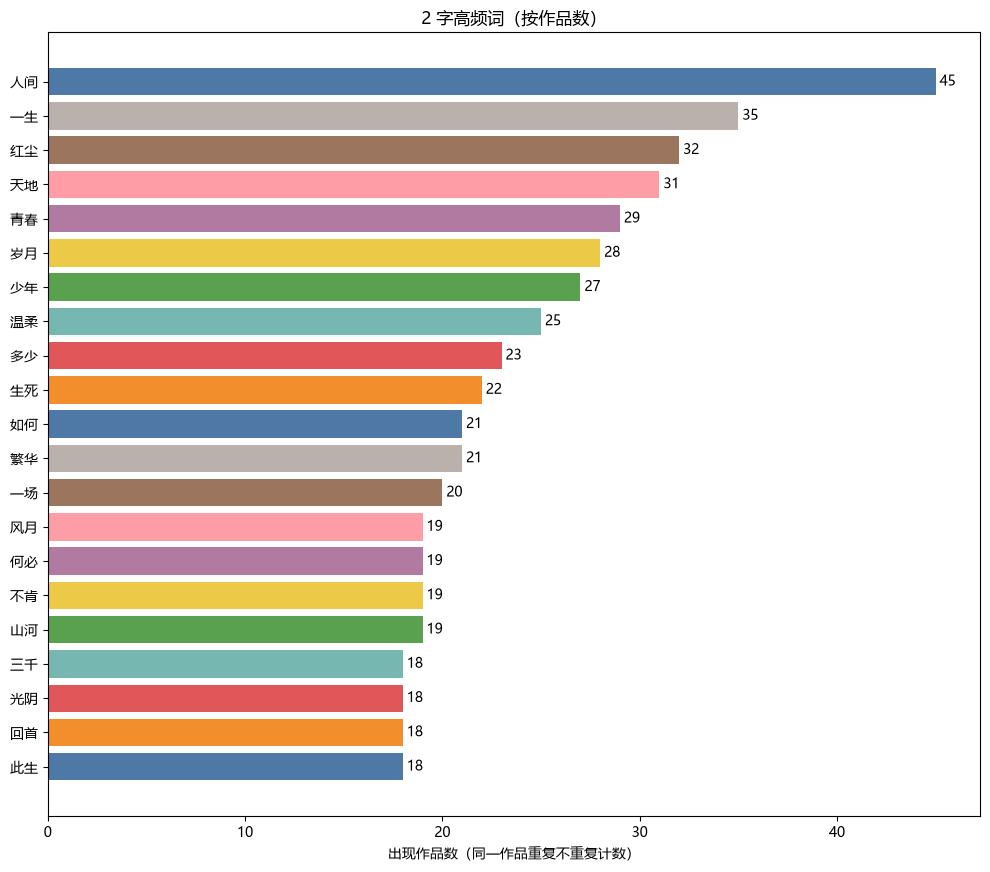

In [4]:
# 将 length 改成 3 或 4，即可画对应字数的高频词图。
ax = plot_frequency(frequency, length=2, top_n=21, title='2 字高频词（按作品数）')
plt.show()
# 需要图片文件时，取消下面一行的注释：
# ax.figure.savefig('2字高频词.png', dpi=180, bbox_inches='tight')

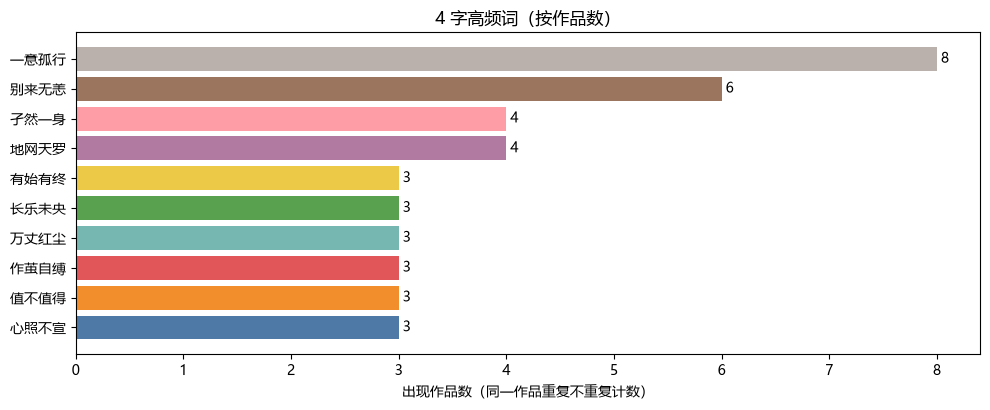

In [5]:
ax = plot_frequency(frequency, length=4, top_n=10, title='4 字高频词（按作品数）')
plt.show()

## 3. 查询

下方是可直接运行的示例。把词语或歌名改成你想查的内容即可。
查词会显示包含该词的完整歌词。

In [ ]:
# 查询「地网天罗」在哪些作品中出现；结果中的「命中歌词」列为该作品中命中的歌词行。
search_word(works, '不肯', user_dict=USER_DICT)

,歌曲名,演唱,命中歌词


In [8]:
# 批量循环测试代码验证鲁棒性

image_keyword = '春夏秋冬风花雪月山川草木雨水冰霜江流海浪云烟尘雾朝日暮光夜梦星河诗词歌赋杯盏茶酒声色舞乐舟船车马亭台楼阁窗门轩榭'
number_keyword = ['零','一','二','三','四','五','六','七','八','九','十','十一','十二','二十四','七十二','百','千','万']

for keyword in number_keyword:
    s = search_word(works, keyword, user_dict=USER_DICT)
    print(keyword, len(s))

零 9
一 130
二 14
三 43
四 14
五 10
六 9
七 13
八 8
九 11
十 35
十一 0
十二 6
二十四 0
七十二 0
百 44
千 90
万 81


In [9]:
# 查询每首歌曲中，排名前 n 的高频词出现了几个，出现了哪些

dataframe = song_high_frequency_words(works, frequency, n=60, user_dict=USER_DICT)

# 1. 设定要打印的行数

# 2. 遍历前 n 行数据并格式化打印
for i, row in dataframe.head(20).iterrows():
    # 3. 自定义输出格式：排名. 歌名 (数量) -> 词语列表
    print(f"《{row['歌曲名']}》(命中: {row['前n高频词数量']}) {row['命中的前n高频词']}")




《千生一见》(命中: 16) 人间、一生、青春、生死、一场、不肯、三千、回首、一夜、不敢、不见、春秋、春风、余生、日月、白发
《无名之月》(命中: 16) 人间、一生、青春、多少、繁华、一场、山河、回首、不见、明月、命运、模样、记得、余生、千年、大梦
《恃宠生忧》(命中: 15) 人间、天地、青春、岁月、少年、温柔、如何、不过、时光、不是、值得、悠悠、不如、春秋、忐忑
《不堪人间》(命中: 14) 人间、红尘、青春、如何、何必、风月、不过、不必、悠悠、不如、忐忑、余生、千年、大梦
《人间未满》(命中: 14) 人间、红尘、天地、青春、温柔、不肯、风月、回首、不必、明月、一声、春风、奈何、白发
《断金》(命中: 14) 人间、天地、青春、岁月、多少、生死、山河、灵魂、不必、天真、往事、一路、宿命、日月
《剑歌应还》(命中: 14) 人间、一生、天地、岁月、少年、一场、三千、回首、一夜、不见、明月、不如、今夜、千年
《婆娑问》(命中: 14) 人间、一生、岁月、少年、多少、繁华、一场、三千、回首、不过、不是、天真、世间、春风
《青蛇》(命中: 13) 人间、红尘、天地、青春、风月、此生、灵魂、心头、悠悠、模样、忐忑、不得、日月
《同谋》(命中: 13) 一生、青春、少年、生死、一场、不肯、不过、天真、往事、命运、一路、千年、宿命
《人间好处》(命中: 13) 人间、少年、温柔、繁华、山河、三千、一夜、不是、心头、春秋、一声、春风、不得
《对黄昏》(命中: 13) 人间、红尘、天地、青春、不肯、何必、光阴、回首、不敢、一世、天真、沉默、白发
《寂寞是》(命中: 13) 一生、天地、岁月、少年、多少、一场、光阴、不必、不是、心头、沉默、记得、世界
《龙与剑之歌》(命中: 13) 多少、不肯、时光、灵魂、不必、不是、值得、往事、不如、命运、灯火、世间、宿命
《繁华唱遍》(命中: 13) 岁月、少年、生死、繁华、不肯、此生、不敢、不过、不是、悠悠、灯火、奈何、白发
《心字书》(命中: 13) 红尘、岁月、生死、回首、此生、不过、往事、明月、一步、春秋、灯火、一路、宿命
《光阴之下》(命中: 12) 一生、岁月、少年、生死、如何、光阴、灵魂、天真、往事、一步、沉默、宿命
《笔绘心卷》(命中: 12) 红尘、天地、温柔、一场、风月、一夜、不过、不必、悠悠、灯火、记得、世间
《藏海花

## 4. 合作者统计

三种口径均以作品数统计，同一人在一首歌中既作曲又编曲也只算一次。

In [10]:
all_collabs = collaborator_frequency(works, '全部合作')
singer_collabs = collaborator_frequency(works, '演唱合作')
music_collabs = collaborator_frequency(works, '曲合作')
print('全部合作（前 20 名）')
display(all_collabs.head(21))
print('演唱合作（前 20 名）')
display(singer_collabs.head(20))
print('曲合作：作曲与编曲合并（前 20 名）')
display(music_collabs.head(20))

全部合作（前 20 名）


,合作者,合作作品数
0,晃儿,27
1,Papaw泡泡,13
2,又又,12
3,露西Lucie,10
4,水一,9
5,Braska,8
6,司夏,6
7,洛天依,6
8,大明,5
9,灰原穷,5


演唱合作（前 20 名）


,合作者,合作作品数
0,晃儿,27
1,水一,9
2,洛天依,6
3,Braska,5
4,Smile_小千,4
5,五音Jw,4
6,司夏,4
7,言和,4
8,说说Crystal,4
9,银临,4


曲合作：作曲与编曲合并（前 20 名）


,合作者,合作作品数
0,Papaw泡泡,13
1,又又,12
2,露西Lucie,10
3,Braska,5
4,大明,5
5,灰原穷,5
6,西门振,5
7,\,4
8,七二四,4
9,张凯颖,4


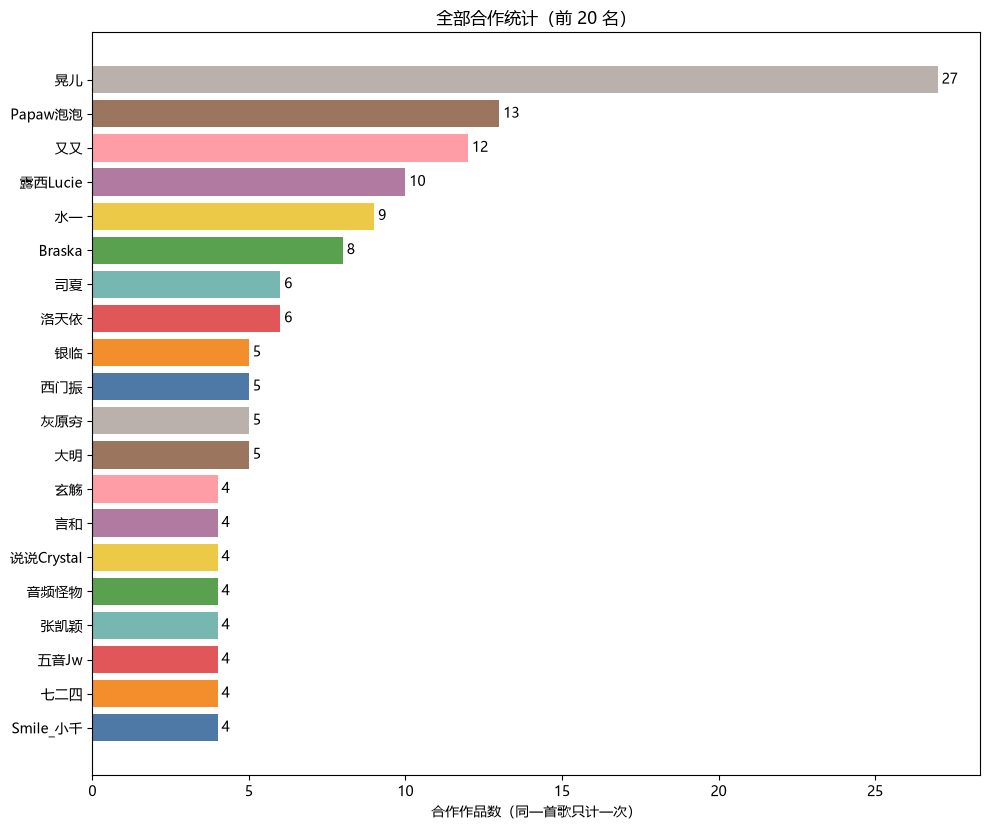

In [11]:
# 把 all_collabs 换成 singer_collabs 或 music_collabs，可绘制另两种合作图。

all_collabs = all_collabs[all_collabs["合作者"] != "\\"].reset_index(drop=True)
ax = plot_collaborators(all_collabs, top_n=20, title='全部合作统计（前 20 名）')
plt.show()

In [28]:
for _, row in all_collabs.iterrows():
    print(*row.values) 

晃儿 27
Papaw泡泡 13
又又 12
露西Lucie 10
水一 9
Braska 8
洛天依 6
司夏 5
大明 5
灰原穷 5
西门振 5
银临 5
Smile_小千 4
七二四 4
五音Jw 4
张凯颖 4
玄觞 4
言和 4
说说Crystal 4
音频怪物 4
黄诗扶 4
GMN宏宇 3
Litterzy 3
Mzf小慕 3
litterzy 3
乐正绫 3
喻川 3
子弥 3
彦Jans 3
贺鑫 3
钟儿蓝 3
CC 2
Tacke竹桑 2
Winky诗 2
wing翼 2
三无Marblue 2
冬子 2
印iAN 2
国风堂 2
城执 2
妮莉安Lily 2
小曲儿 2
少年霜 2
慕寒 2
晴愔 2
朱强 2
梦璟SAYA 2
水云汐Camus 2
汝袖 2
沈谧仁 2
漆柚 2
潇梦临 2
潮汐soron 2
王朝 2
王馨怡 2
简吟 2
纱朵 2
蔡翊昇(贰婶) 2
锦小咕 2
陆深 2
零 2
Akie秋绘 1
Aki阿杰 1
Amuro 1
Asado 1
Assen捷 1
Cuttlefish 1
HITA 1
Minsou 1
O2O男团 1
Polaris 1
Pomelo安妮 1
Sabrina 1
Tureleon 1
Vagary 1
Yusuke Itagaki 1
Zoey 1
alinsun 1
i2star 1
一城CyZ 1
中国绊爱 1
乐正龙牙 1
云の泣 1
云倾少 1
亡海Aries 1
任展成Allen 1
伍觉 1
伦桑 1
伯虎 1
何官锭AL 1
兰音Reine 1
包包 1
千草仙 1
卡卡的音乐世界 1
印iAn 1
只有影子 1
呦猫UNEKO 1
哦漏QAQ 1
唐宋 1
墨清弦 1
夏染鳕玥 1
大门E 1
天钦 1
宁宁 1
宏宇 1
封茗囧菌 1
小义学长 1
小坠 1
小残 1
小龙龙 1
山雨 1
张弘煜 1
张萌川 1
徐一 1
徵羽摩柯 1
戎一 1
排骨教主 1
易羲 1
星尘Infinity 1
李大白 1
李常超 (Lao乾妈) 1
李懋扬(T2o) 1
李星月 1
李蚊香 1
柏鹿 1
柒落Seven 1
柳布 1
樱九 1
欧阳箐宇 1
水墨映像CINK 1
洛萱 1
洪施锐 1
涂山花花 1
清秋秋 1
潇儿 1
潮汐tide 1
王小明 1
王敬轩（妖扬）

## 5. 导出统计表

运行后会在项目根目录的 `output/` 文件夹中生成 Excel 统计结果，
包含全部词频、2/3/4 字词频、三种合作统计。

In [20]:
# 输出到项目根目录的 output/ 文件夹
OUTPUT_DIR = Path('..') / 'output'
output_file = export_tables(OUTPUT_DIR, frequency, works)
print(f'已导出：{output_file.resolve()}')

已导出：D:\My Files\词频统计-Vagary\260720remake\Vagary-main\output\统计结果.xlsx
